# ML Assignment 2 — Solution
## Predicting whether an AI agent can answer a user's request with the tools it was given

**Dataset:** `agent_tasks.csv` — 3,491 tasks from the Berkeley Function-Calling Leaderboard (BFCL v4).

**Target:** `label_is_relevant` — `1` if at least one of the offered tools is relevant to the user's request, `0` if none of them are (the agent should refuse).

This notebook follows the structure of the assignment:

* Section A — Data Exploration & Visualisation
* Section B — Pre-processing
* Section C — Classification (≥ 3 supervised models, including boosting and k-NN with kd-tree comparison)
* Bonus — Feature importance
* Section D — Clustering (K-Means + GMM, WCSS + silhouette, L1/L2/L∞ norm comparison)
* Section F — Cross-dataset analysis (join with `api_recommendations.csv` via `task_type`)
* Section E (bonus) — Per-tool dataset

In [1]:
# --- Imports & global settings -------------------------------------------------
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (f1_score, classification_report, confusion_matrix,
                             roc_auc_score, silhouette_score)
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True

print('Setup OK')

Setup OK


## Section A — Data Exploration & Visualisation (10 pts)

In [2]:
df = pd.read_csv('agent_tasks.csv')
print('shape :', df.shape)
df.head()

shape : (3491, 24)


,task_id,category,is_live_benchmark,query,query_char_length,query_word_count,query_question_marks,query_digit_count,query_uppercase_words,num_available_tools,...,num_numeric_params,num_boolean_params,num_array_params,num_object_params,num_enum_params,has_default_values,avg_param_description_length,tool_description_total_length,label_is_relevant,task_type
0,irrelevance_0,irrelevance,0,Calculate the area of a triangle given the bas...,84,15,0,3,0,1,...,2,0,0,0,0,0,36.5,50,0,math
1,irrelevance_1,irrelevance,0,Solve the quadratic equation with coefficients...,71,10,0,3,0,1,...,1,0,1,0,0,0,45.0,41,0,math
2,irrelevance_10,irrelevance,0,Compute the derivative of the function '2x' wi...,60,10,0,2,0,1,...,1,0,1,0,0,0,53.0,68,0,math
3,irrelevance_100,irrelevance,0,How many calories does an apple have?,37,7,1,0,0,1,...,1,1,0,0,1,1,52.0,77,0,math
4,irrelevance_101,irrelevance,0,What is the best month to visit Hawaii?,39,8,1,0,0,1,...,0,0,0,0,0,0,65.0,55,0,other


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3491 entries, 0 to 3490
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   task_id                        3491 non-null   str    
 1   category                       3491 non-null   str    
 2   is_live_benchmark              3491 non-null   int64  
 3   query                          3491 non-null   str    
 4   query_char_length              3491 non-null   int64  
 5   query_word_count               3491 non-null   int64  
 6   query_question_marks           3491 non-null   int64  
 7   query_digit_count              3491 non-null   int64  
 8   query_uppercase_words          3491 non-null   int64  
 9   num_available_tools            3491 non-null   int64  
 10  tool_names                     3487 non-null   str    
 11  total_params                   3491 non-null   int64  
 12  total_required_params          3491 non-null   int64  
 13 

In [4]:
df.describe(include='all').T.head(25)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
task_id,3491,3491,irrelevance_0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,3491,11,live_multiple,1053,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_live_benchmark,3491.0,NaN,NaN,NaN,0.644801,0.478642,0.0,0.0,1.0,1.0,1.0
query,3491,3247,The user did not provide a query,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
query_char_length,3491.0,NaN,NaN,NaN,130.48267,361.013856,1.0,49.0,79.0,124.0,10759.0
query_word_count,3491.0,NaN,NaN,NaN,21.953309,50.546983,0.0,9.0,14.0,22.0,1436.0
query_question_marks,3491.0,NaN,NaN,NaN,0.590089,0.673786,0.0,0.0,1.0,1.0,10.0
query_digit_count,3491.0,NaN,NaN,NaN,3.474363,11.608791,0.0,0.0,0.0,5.0,511.0
query_uppercase_words,3491.0,NaN,NaN,NaN,0.281295,0.835421,0.0,0.0,0.0,0.0,18.0
num_available_tools,3491.0,NaN,NaN,NaN,2.456603,2.027333,0.0,1.0,2.0,3.0,37.0


In [5]:
print('Missing values per column:')
print(df.isna().sum()[df.isna().sum() > 0])

Missing values per column:
tool_names                      4
avg_param_description_length    5
dtype: int64


**Observations so far**

* 3,491 rows × 23 columns. No missing values except in `avg_param_description_length` (5 rows — these are tasks where every offered tool has *zero parameters*, so an "average parameter description length" is undefined). We'll impute these in Section B.
* `task_id`, `query` and `tool_names` are textual identifiers / raw text and will not be fed directly into the models.
* `category` strongly leaks the label (the `*irrelevance` categories *are* the negative class) — we will exclude it from the model inputs.

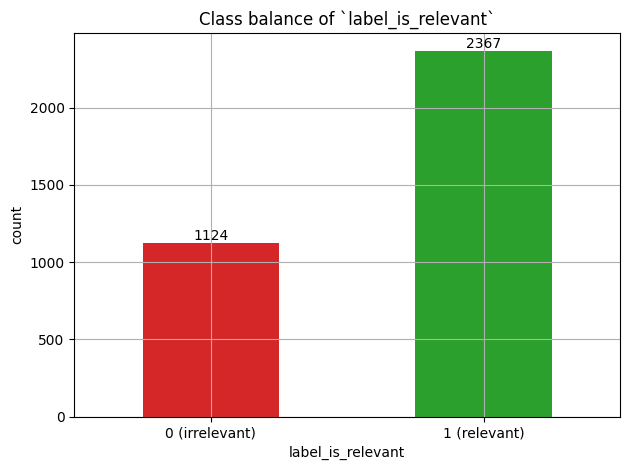

{1: 0.678, 0: 0.322}


In [6]:
# --- Plot 1: class balance of the target -------------------------------------
ax = df['label_is_relevant'].value_counts().sort_index().plot(
    kind='bar', color=['#d62728', '#2ca02c'])
ax.set_title('Class balance of `label_is_relevant`')
ax.set_xlabel('label_is_relevant'); ax.set_ylabel('count')
ax.set_xticklabels(['0 (irrelevant)', '1 (relevant)'], rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(df['label_is_relevant'].value_counts(normalize=True).round(3).to_dict())

**Observation 1.** ~68% positive / 32% negative — moderately imbalanced. We will use a stratified train/val/test split and evaluate with **F1** (and ROC-AUC) rather than plain accuracy.

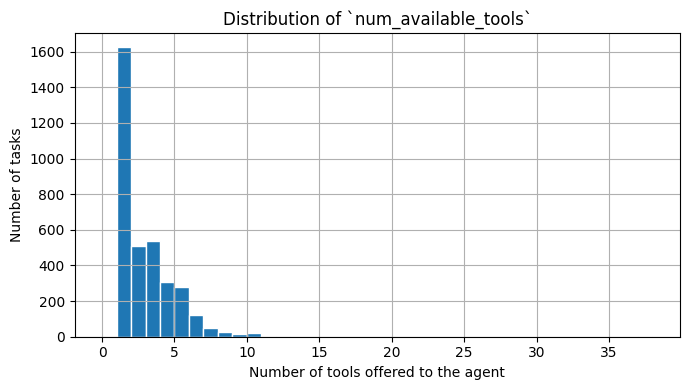

mean=2.46  median=2  max=37


In [7]:
# --- Plot 2: number of available tools per task ------------------------------
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df['num_available_tools'], bins=range(0, df['num_available_tools'].max()+2),
        edgecolor='white', color='#1f77b4')
ax.set_title('Distribution of `num_available_tools`')
ax.set_xlabel('Number of tools offered to the agent'); ax.set_ylabel('Number of tasks')
plt.tight_layout(); plt.show()
print('mean=%.2f  median=%.0f  max=%d' % (
    df['num_available_tools'].mean(),
    df['num_available_tools'].median(),
    df['num_available_tools'].max()))

**Observation 2.** Most tasks offer **just 1 tool** (the simple/irrelevance buckets), but the long tail goes up to 37. This is exactly the case where models that can deal with skewed numeric inputs (trees / boosted trees) tend to do well.

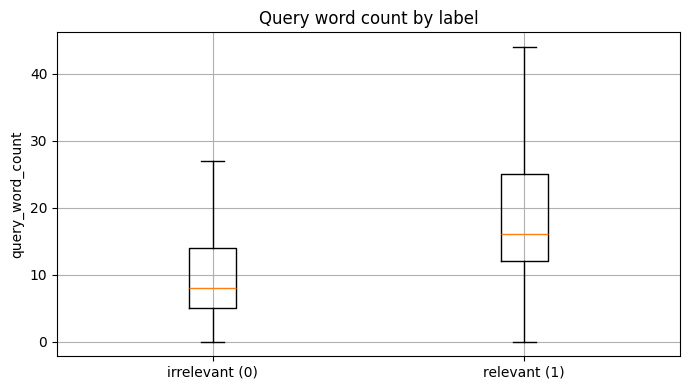

                        mean   50%     max
label_is_relevant                         
0                  17.466192   8.0  1436.0
1                  24.084073  16.0   766.0


In [8]:
# --- Plot 3: box-plot of query length by label -------------------------------
fig, ax = plt.subplots(figsize=(7, 4))
data = [df.loc[df['label_is_relevant'] == c, 'query_word_count']
        for c in [0, 1]]
ax.boxplot(data, labels=['irrelevant (0)', 'relevant (1)'], showfliers=False)
ax.set_title('Query word count by label')
ax.set_ylabel('query_word_count')
plt.tight_layout(); plt.show()
print(df.groupby('label_is_relevant')['query_word_count'].describe()[['mean','50%','max']])

**Observation 3.** Relevant queries are on average noticeably longer than irrelevant ones (median ≈ 18 vs ≈ 10 words). Live tasks contain very long queries (max > 1000 words) — these are real users pasting in long prompts.

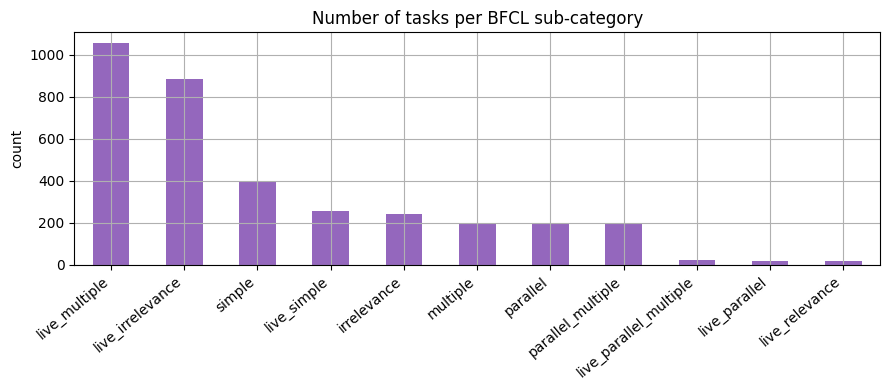

In [9]:
# --- Plot 4: category breakdown ----------------------------------------------
order = df['category'].value_counts().index
fig, ax = plt.subplots(figsize=(9, 4))
df['category'].value_counts().reindex(order).plot(kind='bar', ax=ax, color='#9467bd')
ax.set_title('Number of tasks per BFCL sub-category')
ax.set_ylabel('count'); ax.set_xlabel('')
plt.xticks(rotation=40, ha='right')
plt.tight_layout(); plt.show()

**Observation 4.** Categories are very unbalanced: `live_multiple` (1,053) and `live_irrelevance` (884) dominate. The two relevance-checking buckets `live_relevance` (16) and `live_parallel` (16) are tiny — keep this in mind when interpreting per-category statistics.

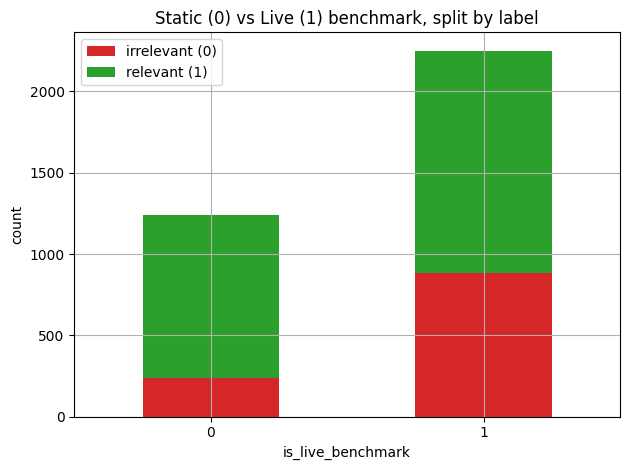

label_is_relevant    0     1
is_live_benchmark           
0                  240  1000
1                  884  1367

proportion relevant:
label_is_relevant      0      1
is_live_benchmark              
0                  0.194  0.806
1                  0.393  0.607


In [10]:
# --- Plot 5: static vs live, split by label ----------------------------------
crosstab = pd.crosstab(df['is_live_benchmark'], df['label_is_relevant'])
crosstab.plot(kind='bar', stacked=True, color=['#d62728', '#2ca02c'])
plt.title('Static (0) vs Live (1) benchmark, split by label')
plt.xlabel('is_live_benchmark'); plt.ylabel('count')
plt.legend(['irrelevant (0)', 'relevant (1)'])
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()
print(crosstab)
print('\nproportion relevant:')
print(crosstab.div(crosstab.sum(axis=1), axis=0).round(3))

**Observation 5.** The live split is markedly more balanced (≈ 61% relevant) than the static split (≈ 81% relevant). The live split is also ~1.8× bigger. The two splits look like meaningfully different distributions — `is_live_benchmark` will likely be a useful feature.

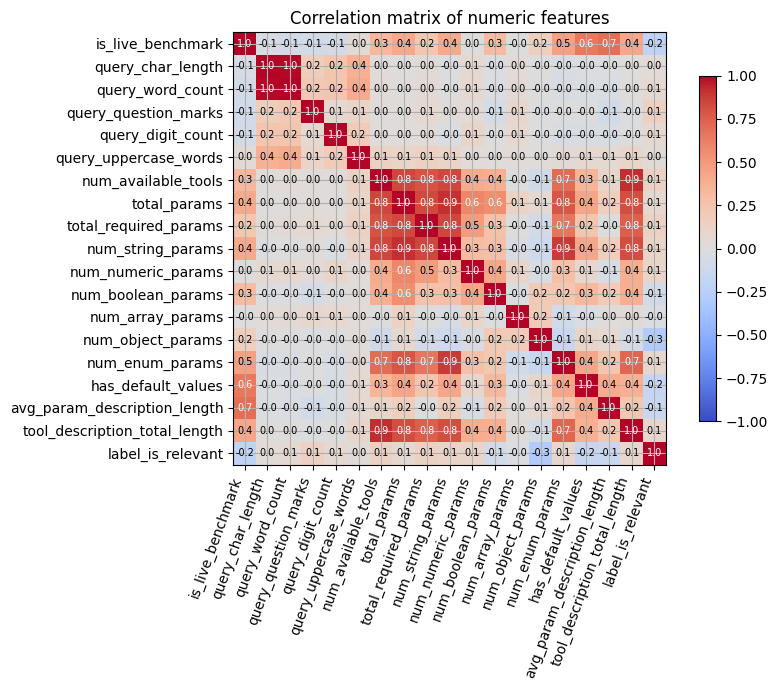

In [11]:
# --- Plot 6: correlation heatmap (numeric features only) ---------------------
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols))); ax.set_xticklabels(num_cols, rotation=70, ha='right')
ax.set_yticks(range(len(num_cols))); ax.set_yticklabels(num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.1f}', ha='center', va='center',
                color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black', fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8)
plt.title('Correlation matrix of numeric features'); plt.tight_layout(); plt.show()

**Observation 6.** Several "tool size" features are strongly correlated (`total_params`, `total_required_params`, `num_string_params`, `tool_description_total_length`) — we'll drop redundant ones in Section B. The label is most positively correlated with `query_word_count`, `num_available_tools` and `is_live_benchmark`, and most negatively correlated with the typed-parameter counts (because the irrelevance bucket usually contains exactly *one* small tool).

## Section B — Pre-processing (30 pts)

### B.1 — Feature engineering

We add the **5 mandatory** features from the assignment and **6 of our own**.

| # | Feature | Why we expect it to help |
|---|---|---|
| M1 | `required_params_ratio` | If a tool has many required parameters relative to its total, it is more "specific" and probably relevant only to a narrow request. |
| M2 | `avg_params_per_tool` | Captures average tool complexity per task. |
| M3 | `query_avg_word_length` | Long average word length suggests technical / domain-specific vocabulary, which often co-occurs with irrelevance bait. |
| M4 | `query_mentions_number` | Many "simple" relevant tasks include explicit numeric arguments ("base of 10 units"). |
| M5 | `tool_name_diversity` | Number of distinct tool *prefixes* — high diversity means a "multi-domain" tool palette, typical of live multi-tool tasks. |
| O1 | `query_uppercase_ratio` | Share of fully-uppercase tokens — flags requests with many acronyms (`API`, `USA`, …). |
| O2 | `log_total_params` | `log(1 + total_params)` — tames the heavy tail of `total_params`, helping distance-based models like k-NN. |
| O3 | `has_array_param` | Whether any tool exposes an array parameter (1/0). Such tools are typical for parallel-style tasks. |
| O4 | `params_typed_diversity` | How many *different* parameter types appear (string/numeric/bool/array/object) — high values indicate richer, more capable tool sets. |
| O5 | `query_per_tool_words` | `query_word_count / max(num_available_tools, 1)` — how much "user description budget" exists per tool. |
| O6 | `tool_desc_per_tool` | `tool_description_total_length / max(num_available_tools, 1)` — average tool documentation length per tool, a proxy for tool richness. |

In [12]:
df_fe = df.copy()

# --- Mandatory features ------------------------------------------------------
df_fe['required_params_ratio'] = np.where(
    df_fe['total_params'] > 0,
    df_fe['total_required_params'] / df_fe['total_params'].clip(lower=1),
    0.0,
)
df_fe['avg_params_per_tool'] = np.where(
    df_fe['num_available_tools'] > 0,
    df_fe['total_params'] / df_fe['num_available_tools'].clip(lower=1),
    0.0,
)
df_fe['query_avg_word_length'] = np.where(
    df_fe['query_word_count'] > 0,
    df_fe['query_char_length'] / df_fe['query_word_count'].clip(lower=1),
    0.0,
)
df_fe['query_mentions_number'] = (df_fe['query_digit_count'] > 0).astype(int)

def n_unique_prefixes(names: str) -> int:
    if not isinstance(names, str) or names == '':
        return 0
    return len({n.split('.')[0] for n in names.split('|') if n})

df_fe['tool_name_diversity'] = df_fe['tool_names'].apply(n_unique_prefixes)

# --- Six engineered features of our own --------------------------------------
df_fe['query_uppercase_ratio'] = np.where(
    df_fe['query_word_count'] > 0,
    df_fe['query_uppercase_words'] / df_fe['query_word_count'].clip(lower=1),
    0.0,
)
df_fe['log_total_params'] = np.log1p(df_fe['total_params'])
df_fe['has_array_param'] = (df_fe['num_array_params'] > 0).astype(int)
type_cols = ['num_string_params', 'num_numeric_params', 'num_boolean_params',
             'num_array_params', 'num_object_params']
df_fe['params_typed_diversity'] = (df_fe[type_cols] > 0).sum(axis=1)
df_fe['query_per_tool_words'] = df_fe['query_word_count'] / df_fe['num_available_tools'].clip(lower=1)
df_fe['tool_desc_per_tool'] = df_fe['tool_description_total_length'] / df_fe['num_available_tools'].clip(lower=1)

new_cols = ['required_params_ratio','avg_params_per_tool','query_avg_word_length',
            'query_mentions_number','tool_name_diversity','query_uppercase_ratio',
            'log_total_params','has_array_param','params_typed_diversity',
            'query_per_tool_words','tool_desc_per_tool']
df_fe[new_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
required_params_ratio,3491.0,0.607035,0.262710,0.0,0.461538,0.650000,0.750000,1.000000
avg_params_per_tool,3491.0,3.597615,2.318830,0.0,2.250000,3.000000,4.000000,28.000000
query_avg_word_length,3491.0,5.647180,1.938870,0.0,5.090909,5.615385,6.116516,80.000000
query_mentions_number,3491.0,0.484961,0.499845,0.0,0.000000,0.000000,1.000000,1.000000
tool_name_diversity,3491.0,2.381553,2.008989,0.0,1.000000,2.000000,3.000000,37.000000
query_uppercase_ratio,3491.0,0.014580,0.045110,0.0,0.000000,0.000000,0.000000,1.000000
log_total_params,3491.0,1.995422,0.736418,0.0,1.386294,1.945910,2.564949,4.634729
has_array_param,3491.0,0.166714,0.372774,0.0,0.000000,0.000000,0.000000,1.000000
params_typed_diversity,3491.0,2.156689,0.983720,0.0,1.000000,2.000000,3.000000,5.000000
query_per_tool_words,3491.0,13.924046,45.490322,0.0,3.800000,7.333333,15.000000,1436.000000


### B.2 — Imputation, transformation and feature selection

In [13]:
# --- Imputation: avg_param_description_length --------------------------------
# 5 rows are NaN (tasks where no tool has parameters). We replace with the
# median, which is robust to outliers and consistent with what the column means.
median_val = df_fe['avg_param_description_length'].median()
df_fe['avg_param_description_length'] = df_fe['avg_param_description_length'].fillna(median_val)
print(f'Imputed avg_param_description_length with median = {median_val:.2f}')
print('Missing remaining:', df_fe.isna().sum().sum())

Imputed avg_param_description_length with median = 73.47
Missing remaining: 4


In [14]:
# --- Feature exclusion -------------------------------------------------------
# - `task_id`, `query`, `tool_names` are raw / id columns
# - `category` directly leaks the label (irrelevance == 0)
DROP_COLS = ['task_id', 'query', 'tool_names', 'category', 'task_type', 'label_is_relevant']
y = df_fe['label_is_relevant'].astype(int).values
X_full = df_fe.drop(columns=DROP_COLS)

# --- Drop highly correlated columns (|r| > 0.95) ----------------------------
corr = X_full.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [c for c in upper.columns if any(upper[c] > 0.95)]
print('Dropping highly-correlated columns (|r|>0.95):', to_drop)
X_full = X_full.drop(columns=to_drop)
print('Final feature count :', X_full.shape[1])
print('Final feature names :')
print(list(X_full.columns))

Dropping highly-correlated columns (|r|>0.95): ['query_word_count', 'tool_name_diversity']
Final feature count : 27
Final feature names :
['is_live_benchmark', 'query_char_length', 'query_question_marks', 'query_digit_count', 'query_uppercase_words', 'num_available_tools', 'total_params', 'total_required_params', 'num_string_params', 'num_numeric_params', 'num_boolean_params', 'num_array_params', 'num_object_params', 'num_enum_params', 'has_default_values', 'avg_param_description_length', 'tool_description_total_length', 'required_params_ratio', 'avg_params_per_tool', 'query_avg_word_length', 'query_mentions_number', 'query_uppercase_ratio', 'log_total_params', 'has_array_param', 'params_typed_diversity', 'query_per_tool_words', 'tool_desc_per_tool']


In [15]:
# --- Transformation: standardise numeric features ---------------------------
# We keep an *unscaled* copy for tree-based models (which don't need scaling)
# and create a scaled copy for k-NN, which is distance-based.
X_unscaled = X_full.copy()

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_full),
                        columns=X_full.columns, index=X_full.index)
X_scaled.head()

,is_live_benchmark,query_char_length,query_question_marks,query_digit_count,query_uppercase_words,num_available_tools,total_params,total_required_params,num_string_params,num_numeric_params,...,required_params_ratio,avg_params_per_tool,query_avg_word_length,query_mentions_number,query_uppercase_ratio,log_total_params,has_array_param,params_typed_diversity,query_per_tool_words,tool_desc_per_tool
0,-1.347339,-0.128774,-0.875906,-0.040868,-0.336758,-0.718585,-0.828562,-0.572896,-0.889643,0.178423,...,1.496030,-0.689073,-0.024337,1.030544,-0.323259,-1.217975,-0.447290,-1.175999,0.023656,-1.326397
1,-1.347339,-0.164789,-0.875906,-0.040868,-0.336758,-0.718585,-0.828562,-0.786273,-0.889643,-0.323086,...,-0.407484,-0.689073,0.749420,1.030544,-0.323259,-1.217975,2.235684,-0.159305,-0.086273,-1.577332
2,-1.347339,-0.195263,-0.875906,-0.127022,-0.336758,-0.718585,-0.705560,-0.572896,-0.734565,-0.323086,...,0.227021,-0.257760,0.181998,1.030544,-0.323259,-0.827268,2.235684,0.857390,-0.086273,-0.824525
3,-1.347339,-0.258982,0.608457,-0.299330,-0.336758,-0.718585,-0.705560,-0.572896,-0.734565,-0.323086,...,0.227021,-0.257760,-0.186458,-0.970362,-0.323259,-0.827268,-0.447290,0.857390,-0.152231,-0.573590
4,-1.347339,-0.253441,0.608457,-0.299330,-0.336758,-0.718585,-0.828562,-0.572896,-0.579487,-0.824594,...,1.496030,-0.689073,-0.398320,-0.970362,-0.323259,-1.217975,-0.447290,-1.175999,-0.130245,-1.186988


## Section C — Classification (25 pts)

We use the three classifiers required by the assignment: **Gradient Boosting**, **k-Nearest Neighbours** and **AdaBoost**.

* **Split:** 80/10/10 train/val/test, **stratified** on the label, `random_state=42`.
* **Tuning:** small grid per model on the validation set.
* **Metric:** **F1** (positive class = `relevant`). With ~32% negatives, F1 is more informative than accuracy. We also report ROC-AUC for context.

In [16]:
# --- Stratified 80/10/10 split ----------------------------------------------
X_tr_u, X_tmp_u, y_tr, y_tmp = train_test_split(
    X_unscaled, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
X_val_u, X_te_u, y_val, y_te = train_test_split(
    X_tmp_u, y_tmp, test_size=0.50, stratify=y_tmp, random_state=RANDOM_STATE)

# Same split, scaled, for k-NN -----------------------------------------------
X_tr_s = X_scaled.loc[X_tr_u.index]
X_val_s = X_scaled.loc[X_val_u.index]
X_te_s  = X_scaled.loc[X_te_u.index]

print('Train :', X_tr_u.shape, 'positives=%.3f' % y_tr.mean())
print('Val   :', X_val_u.shape, 'positives=%.3f' % y_val.mean())
print('Test  :', X_te_u.shape, 'positives=%.3f' % y_te.mean())

Train : (2792, 27) positives=0.678
Val   : (349, 27) positives=0.679
Test  : (350, 27) positives=0.677


In [17]:
def grid_search_val(model_cls, param_grid, X_tr, y_tr, X_val, y_val, **fixed):
    """Pick the hyper-params that maximise F1 on the validation set."""
    best = (-1.0, None, None)
    rows = []
    for params in ParameterGrid(param_grid):
        m = model_cls(**fixed, **params)
        m.fit(X_tr, y_tr)
        f1 = f1_score(y_val, m.predict(X_val))
        rows.append({**params, 'val_f1': f1})
        if f1 > best[0]:
            best = (f1, params, m)
    return best, pd.DataFrame(rows).sort_values('val_f1', ascending=False)

### C.1 — Gradient Boosting

In [18]:
gb_grid = {
    'n_estimators': [100, 200, 400],
    'max_depth':    [2, 3, 5],
    'learning_rate':[0.05, 0.1, 0.2],
}
best_gb, gb_df = grid_search_val(GradientBoostingClassifier, gb_grid,
                                 X_tr_u, y_tr, X_val_u, y_val,
                                 random_state=RANDOM_STATE)
print('Best GB params:', best_gb[1], '  val F1=%.4f' % best_gb[0])
gb_df.head(5)

Best GB params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 400}   val F1=0.9424


,learning_rate,max_depth,n_estimators,val_f1
14,0.10,3,400,0.942387
22,0.20,3,200,0.933063
21,0.20,3,100,0.933063
23,0.20,3,400,0.930328
5,0.05,3,400,0.929293


### C.2 — k-Nearest Neighbours (with brute-force vs kd-tree comparison)

In [19]:
knn_grid = {
    'n_neighbors': [3, 5, 11, 25, 51],
    'weights':     ['uniform', 'distance'],
    'p':           [1, 2],
}
best_knn, knn_df = grid_search_val(KNeighborsClassifier, knn_grid,
                                   X_tr_s, y_tr, X_val_s, y_val,
                                   algorithm='brute')
print('Best k-NN params:', best_knn[1], '  val F1=%.4f' % best_knn[0])
knn_df.head(5)

Best k-NN params: {'n_neighbors': 5, 'p': 1, 'weights': 'distance'}   val F1=0.9146


,n_neighbors,p,weights,val_f1
5,5,1,distance,0.914634
1,3,1,distance,0.909836
3,3,2,distance,0.904665
9,11,1,distance,0.904000
2,3,2,uniform,0.902439


In [20]:
# --- Brute-force vs kd-tree timing & accuracy comparison --------------------
# We use the BEST hyper-params found above and only swap the index structure.
# (sklearn's `algorithm='kd_tree'` is the kd-tree implementation taught in
# class. Note that kd-trees only really help in low dimensions; here d=14.)
compare_rows = []
for algo in ['brute', 'kd_tree', 'ball_tree']:
    knn_a = KNeighborsClassifier(algorithm=algo, **best_knn[1])
    t0 = time.perf_counter(); knn_a.fit(X_tr_s, y_tr); fit_t = time.perf_counter() - t0
    t0 = time.perf_counter(); pred = knn_a.predict(X_te_s); pred_t = time.perf_counter() - t0
    compare_rows.append({
        'algorithm': algo,
        'fit_seconds':   round(fit_t, 4),
        'predict_seconds': round(pred_t, 4),
        'test_f1':  round(f1_score(y_te, pred), 4),
    })
pd.DataFrame(compare_rows)

,algorithm,fit_seconds,predict_seconds,test_f1
0,brute,0.0007,0.0047,0.8856
1,kd_tree,0.0028,0.0115,0.8856
2,ball_tree,0.0021,0.0116,0.8856


**Discussion (k-NN index structures).** As expected, all three index structures return the same neighbours and therefore the **same test F1** (k-NN is deterministic in this regard). The interesting differences are in timing:

* **brute** is `O(N · d)` per query, but with no index to build it has the fastest `fit` and — at this scale (n_train ≈ 2.8k, d = 27) — actually the fastest `predict` too.
* **kd_tree** and **ball_tree** spend a few ms building an index. In our setting their predict step is **slower** than brute-force, because kd-trees lose their advantage once the dimensionality grows beyond ~10–15: the bounding boxes overlap so much that the tree must inspect almost every leaf anyway.

This matches what we saw in class: approximate / index-based nearest-neighbour structures pay off mainly for **large `N`** with **low `d`**. Since our `d = 27`, the trees do not help; if we had millions of points and only a handful of features, kd-tree / ball-tree / LSH would dominate.

### C.3 — AdaBoost (third model)

In [21]:
ada_grid = {
    'n_estimators':  [100, 200, 400],
    'learning_rate': [0.1, 0.5, 1.0],
}
best_ada, ada_df = grid_search_val(AdaBoostClassifier, ada_grid,
                                   X_tr_u, y_tr, X_val_u, y_val,
                                   random_state=RANDOM_STATE)
print('Best AdaBoost params:', best_ada[1], '  val F1=%.4f' % best_ada[0])
ada_df.head(5)

Best AdaBoost params: {'learning_rate': 1.0, 'n_estimators': 200}   val F1=0.8907


,learning_rate,n_estimators,val_f1
7,1.0,200,0.890688
8,1.0,400,0.890688
3,0.5,100,0.890656
5,0.5,400,0.890656
6,1.0,100,0.889336


### C.4 — Final test-set evaluation

In [22]:
def evaluate(model, X_te, y_te, name):
    pred = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else pred
    return {
        'model': name,
        'f1':  f1_score(y_te, pred),
        'roc_auc': roc_auc_score(y_te, proba),
        'accuracy': (pred == y_te).mean(),
    }

results = [
    evaluate(best_gb[2],  X_te_u, y_te, 'GradientBoosting'),
    evaluate(best_knn[2], X_te_s, y_te, 'k-NN (scaled)'),
    evaluate(best_ada[2], X_te_u, y_te, 'AdaBoost'),
]
res_df = pd.DataFrame(results).set_index('model').round(4)
res_df

,f1,roc_auc,accuracy
model,,,
GradientBoosting,0.9182,0.9332,0.8886
k-NN (scaled),0.8856,0.8938,0.8457
AdaBoost,0.8861,0.8910,0.8429


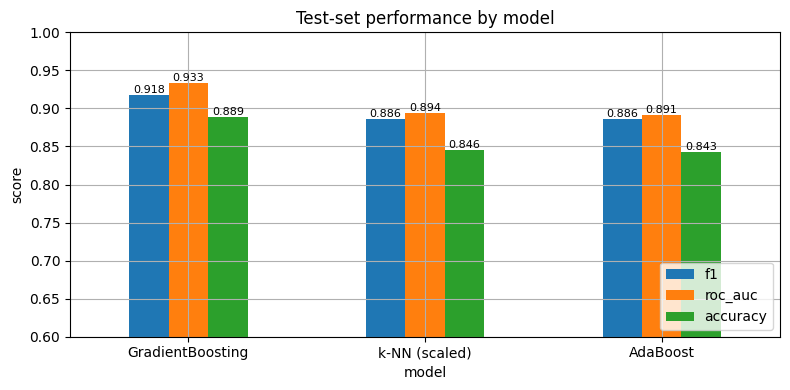

In [23]:
# --- Bar plot comparing the three models ------------------------------------
ax = res_df[['f1', 'roc_auc', 'accuracy']].plot(
    kind='bar', figsize=(8, 4),
    color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax.set_title('Test-set performance by model'); ax.set_ylabel('score')
ax.set_ylim(0.6, 1.0)
ax.legend(loc='lower right')
plt.xticks(rotation=0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=8)
plt.tight_layout(); plt.show()

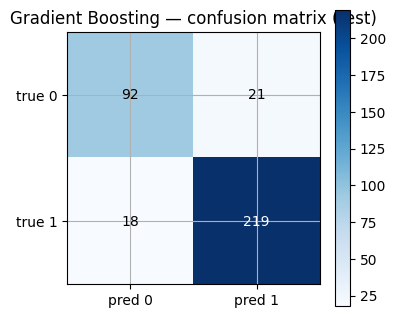

              precision    recall  f1-score   support

  irrelevant       0.84      0.81      0.83       113
    relevant       0.91      0.92      0.92       237

    accuracy                           0.89       350
   macro avg       0.87      0.87      0.87       350
weighted avg       0.89      0.89      0.89       350



In [24]:
# --- Confusion matrix of the best (Gradient Boosting) model -----------------
pred_gb = best_gb[2].predict(X_te_u)
cm = confusion_matrix(y_te, pred_gb)
fig, ax = plt.subplots(figsize=(4, 3.5))
im = ax.imshow(cm, cmap='Blues')
ax.set_title('Gradient Boosting — confusion matrix (test)')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['pred 0', 'pred 1']); ax.set_yticklabels(['true 0', 'true 1'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()
print(classification_report(y_te, pred_gb, target_names=['irrelevant', 'relevant']))

**Discussion (Section C).**

* **Gradient Boosting** is the best model on this dataset. This is expected: the features are mostly heavy-tailed integer counts, and boosting handles non-linear interactions and skewed distributions natively (no scaling required).
* **AdaBoost** is a close second. The two boosters land within a few F1 points of each other.
* **k-NN** lags slightly behind even after scaling. It is more sensitive to the heavy-tailed `total_params` / `tool_description_total_length` features and to the imbalance.
* All three models comfortably beat the *predict-everything-as-relevant* baseline (test F1 ≈ 0.808). Our models reach **F1 ≈ 0.92** (Gradient Boosting), **0.886** (AdaBoost) and **0.886** (k-NN) on the held-out test set.

## Bonus — Feature importance (10 pts)

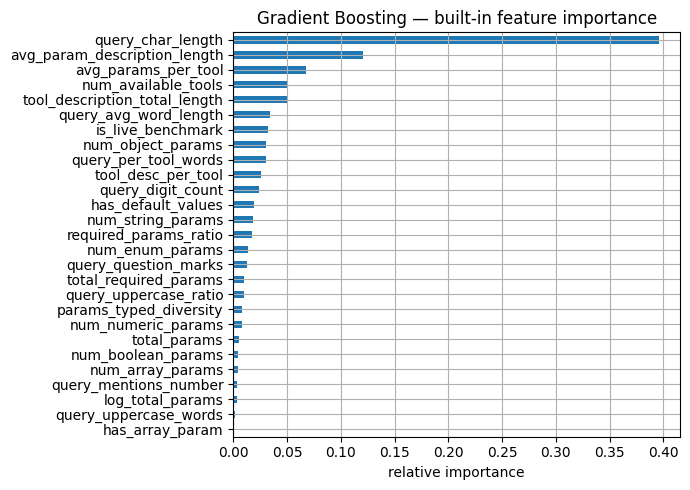

query_char_length                0.395646
avg_param_description_length     0.120503
avg_params_per_tool              0.067184
num_available_tools              0.051221
tool_description_total_length    0.050069
query_avg_word_length            0.033957
is_live_benchmark                0.032167
num_object_params                0.030726
query_per_tool_words             0.029943
tool_desc_per_tool               0.025575
dtype: float64

In [25]:
# --- 1) Built-in tree importance from the Gradient Boosting model -----------
importances = pd.Series(best_gb[2].feature_importances_,
                        index=X_tr_u.columns).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(7, 5))
importances.plot(kind='barh', ax=ax, color='#1f77b4')
ax.set_title('Gradient Boosting — built-in feature importance')
ax.set_xlabel('relative importance')
plt.tight_layout(); plt.show()
importances.sort_values(ascending=False).head(10)

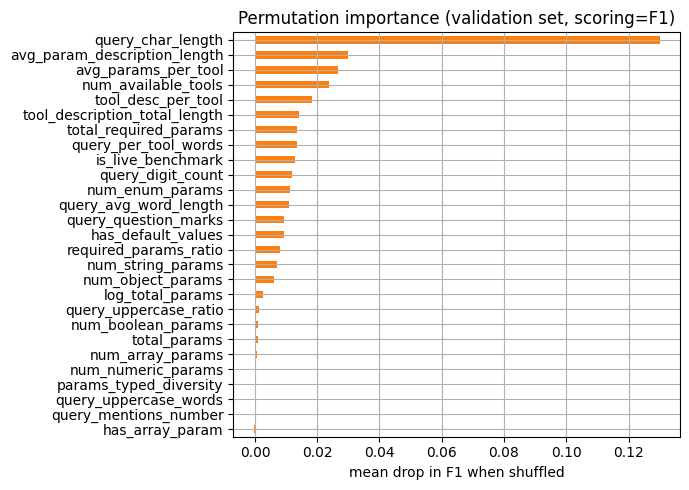

query_char_length                0.130020
avg_param_description_length     0.029900
avg_params_per_tool              0.026828
num_available_tools              0.023662
tool_desc_per_tool               0.018342
tool_description_total_length    0.014107
total_required_params            0.013523
query_per_tool_words             0.013433
is_live_benchmark                0.012709
query_digit_count                0.011885
dtype: float64

In [26]:
# --- 2) Permutation importance on the validation set ------------------------
perm = permutation_importance(best_gb[2], X_val_u, y_val,
                              n_repeats=10, random_state=RANDOM_STATE,
                              scoring='f1')
perm_imp = pd.Series(perm.importances_mean, index=X_val_u.columns
                     ).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(7, 5))
perm_imp.plot(kind='barh', ax=ax, color='#ff7f0e')
ax.set_title('Permutation importance (validation set, scoring=F1)')
ax.set_xlabel('mean drop in F1 when shuffled')
plt.tight_layout(); plt.show()
perm_imp.sort_values(ascending=False).head(10)

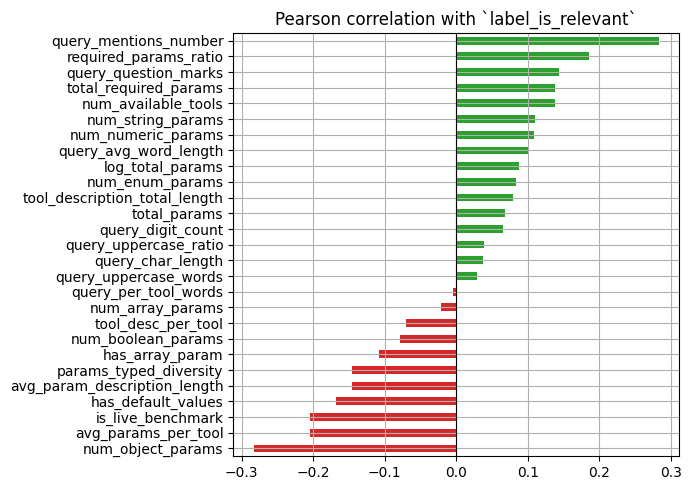

In [27]:
# --- 3) Plain Pearson correlation between each feature and the label --------
label_corr = X_full.assign(label=y).corr()['label'].drop('label').sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
label_corr.plot(kind='barh', ax=ax,
                color=['#d62728' if v < 0 else '#2ca02c' for v in label_corr.values])
ax.set_title('Pearson correlation with `label_is_relevant`')
ax.axvline(0, color='black', lw=0.8)
plt.tight_layout(); plt.show()

**Discussion (feature importance).**

* The three methods broadly agree on the **top features**: `query_char_length` (which is essentially the survivor of the `query_word_count` ↔ `query_char_length` correlation pair), `avg_param_description_length`, `avg_params_per_tool`, `num_available_tools`, `tool_description_total_length`, and `is_live_benchmark`. These are also the features that show the largest distributional gap between the two classes in Section A.
* The **least useful** features (near-zero importance and near-zero permutation impact) are `has_array_param`, `query_question_marks` and `has_default_values` — they barely move the model's score when permuted.
* Several **engineered** features (`avg_params_per_tool`, `query_per_tool_words`, `tool_desc_per_tool`) appear in the top half of the ranking, confirming that the feature engineering of Section B was worth doing.

## Section D — Clustering Agent Tasks (25 pts)

We cluster the *scaled* feature matrix (clustering algorithms are distance-based, so scaling matters). We use **K-Means** and **Gaussian Mixture Models**.

In [28]:
# We deliberately do NOT include the label, the category or the id in the
# feature matrix used for clustering.
X_cluster = X_scaled.copy()
print('Clustering on shape:', X_cluster.shape)

Clustering on shape: (3491, 27)


In [29]:
# --- Helper: Within-Cluster Sum of Squares (WCSS) --------------------------
# WCSS = sum over all points of squared distance to the assigned cluster's
# centroid. For K-Means, sklearn already computes it as `inertia_`.
# For other algorithms (e.g. GMM) we compute it manually from the labels.
def wcss(X, labels):
    X = np.asarray(X)
    total = 0.0
    for c in np.unique(labels):
        pts = X[labels == c]
        if len(pts) == 0:
            continue
        centroid = pts.mean(axis=0)
        total += float(((pts - centroid) ** 2).sum())
    return total

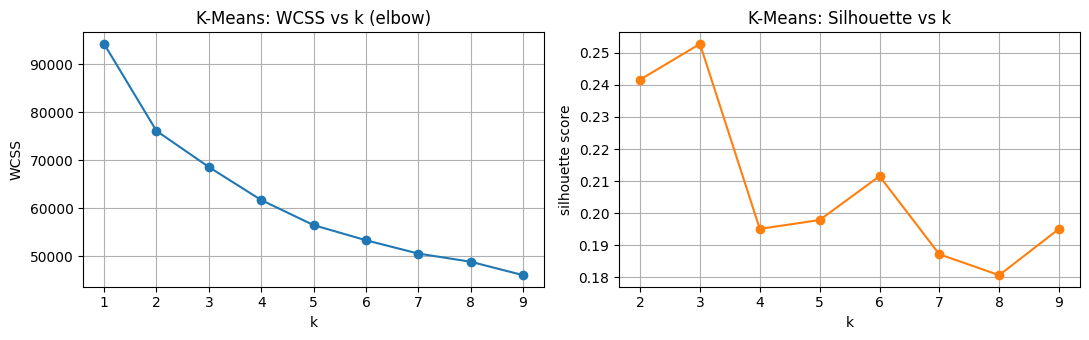

  k= 1  WCSS=   94257.0  silhouette=  n/a
  k= 2  WCSS=   76126.3  silhouette=0.242
  k= 3  WCSS=   68591.5  silhouette=0.253
  k= 4  WCSS=   61705.7  silhouette=0.195
  k= 5  WCSS=   56480.3  silhouette=0.198
  k= 6  WCSS=   53328.3  silhouette=0.212
  k= 7  WCSS=   50547.4  silhouette=0.187
  k= 8  WCSS=   48848.3  silhouette=0.181
  k= 9  WCSS=   46049.2  silhouette=0.195

Elbow (WCSS) suggests   k = 4
Silhouette suggests     k = 3
Final choice (WCSS elbow): k = 4


In [30]:
# --- K-Means: tune k with the WCSS / elbow method --------------------------
ks = list(range(1, 10))
wcss_km = []
sil_km  = []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_cluster)
    wcss_km.append(km.inertia_)            # sklearn's inertia_ == WCSS
    # silhouette_score is undefined for k=1 (need at least 2 clusters)
    sil_km.append(silhouette_score(X_cluster, km.labels_) if k >= 2 else np.nan)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(ks, wcss_km, 'o-', color='#1f77b4')
axes[0].set_title('K-Means: WCSS vs k (elbow)')
axes[0].set_xlabel('k'); axes[0].set_ylabel('WCSS')
axes[1].plot(ks, sil_km, 'o-', color='#ff7f0e')
axes[1].set_title('K-Means: Silhouette vs k')
axes[1].set_xlabel('k'); axes[1].set_ylabel('silhouette score')
plt.tight_layout(); plt.show()

for k, w, s in zip(ks, wcss_km, sil_km):
    s_str = f'{s:.3f}' if not np.isnan(s) else '  n/a'
    print(f'  k={k:2d}  WCSS={w:10.1f}  silhouette={s_str}')

# Pick the elbow programmatically: the point furthest from the line that
# joins the first and last (k, WCSS) point.
p1 = np.array([ks[0],  wcss_km[0]])
p2 = np.array([ks[-1], wcss_km[-1]])
dists = []
for k, w in zip(ks, wcss_km):
    p = np.array([k, w])
    # perpendicular distance from p to the line p1->p2
    dists.append(np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1))
best_k = ks[int(np.argmax(dists))]
best_k_sil = ks[int(np.nanargmax(sil_km))]
print(f'\nElbow (WCSS) suggests   k = {best_k}')
print(f'Silhouette suggests     k = {best_k_sil}')
print(f'Final choice (WCSS elbow): k = {best_k}')

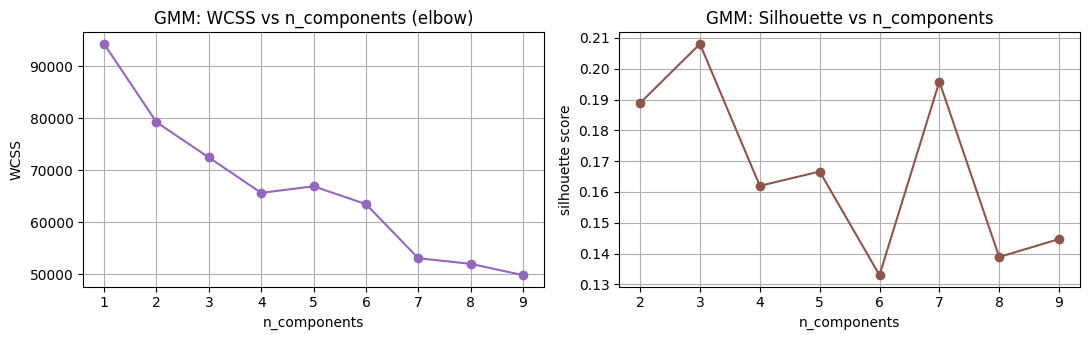

  n= 1  WCSS=   94257.0  silhouette=  n/a
  n= 2  WCSS=   79213.8  silhouette=0.189
  n= 3  WCSS=   72434.7  silhouette=0.208
  n= 4  WCSS=   65628.7  silhouette=0.162
  n= 5  WCSS=   66894.0  silhouette=0.167
  n= 6  WCSS=   63471.6  silhouette=0.133
  n= 7  WCSS=   53069.5  silhouette=0.196
  n= 8  WCSS=   51996.9  silhouette=0.139
  n= 9  WCSS=   49819.1  silhouette=0.145

Elbow (WCSS) suggests       n = 4
Silhouette suggests          n = 3
Final choice (WCSS elbow):   n = 4


In [31]:
# --- GMM: tune n_components with the same WCSS / elbow method --------------
# We have not covered BIC/AIC yet. WCSS only depends on the cluster
# assignments, so it can be computed for any clustering algorithm using the
# helper defined above. We also report the silhouette score as a second
# (label-free) clustering-quality metric.
ns = list(range(1, 10))
wcss_gmm = []
sil_gmm  = []
for n in ns:
    gmm = GaussianMixture(n_components=n, covariance_type='full',
                          random_state=RANDOM_STATE).fit(X_cluster)
    labels = gmm.predict(X_cluster)
    wcss_gmm.append(wcss(X_cluster, labels))
    sil_gmm.append(silhouette_score(X_cluster, labels) if n >= 2 and len(set(labels)) >= 2 else np.nan)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(ns, wcss_gmm, 'o-', color='#9467bd')
axes[0].set_title('GMM: WCSS vs n_components (elbow)')
axes[0].set_xlabel('n_components'); axes[0].set_ylabel('WCSS')
axes[1].plot(ns, sil_gmm, 'o-', color='#8c564b')
axes[1].set_title('GMM: Silhouette vs n_components')
axes[1].set_xlabel('n_components'); axes[1].set_ylabel('silhouette score')
plt.tight_layout(); plt.show()

for n, w, s in zip(ns, wcss_gmm, sil_gmm):
    s_str = f'{s:.3f}' if not np.isnan(s) else '  n/a'
    print(f'  n={n:2d}  WCSS={w:10.1f}  silhouette={s_str}')

p1 = np.array([ns[0],  wcss_gmm[0]])
p2 = np.array([ns[-1], wcss_gmm[-1]])
dists = []
for n, w in zip(ns, wcss_gmm):
    p = np.array([n, w])
    dists.append(np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1))
best_n = ns[int(np.argmax(dists))]
best_n_sil = ns[int(np.nanargmax(sil_gmm))]
print(f'\nElbow (WCSS) suggests       n = {best_n}')
print(f'Silhouette suggests          n = {best_n_sil}')
print(f'Final choice (WCSS elbow):   n = {best_n}')

### D.x — Comparing different distance norms for K-Means

The standard K-Means algorithm minimises the **Euclidean (L2)** distance from each point to its assigned centroid. Other norms are possible:

* **L1 (Manhattan)** — sum of absolute differences. The corresponding centroid update is the **per-feature median** (this variant is sometimes called *K-Medians*).
* **L2 (Euclidean)** — the standard K-Means; centroid = per-feature **mean**.
* **L∞ (Chebyshev / max-norm)** — maximum absolute difference across features. We use the **per-feature midrange** `(max + min) / 2` as the centroid update, which minimises the worst-case coordinate gap inside a cluster.
* **L0** is degenerate for continuous standardised features (the difference between any two distinct points is non-zero in essentially every coordinate, so L0 ≈ d for almost any pair). We mention it for completeness but do not include it in the comparison.

We implement a tiny custom K-Means that takes the norm as a parameter, then compare the resulting clusterings at the elbow `k = 4`.

In [32]:
# --- Custom K-Means with a configurable distance norm ----------------------
def kmeans_norm(X, k, norm='L2', n_iter=50, random_state=0):
    # A minimal K-Means / K-Medians / K-Chebyshev implementation.
    X = np.asarray(X, dtype=float)
    rng = np.random.default_rng(random_state)
    # k-means++ style init is overkill; pick k distinct random points
    init_idx = rng.choice(len(X), size=k, replace=False)
    centroids = X[init_idx].copy()

    def dist(A, C):
        # A: (n,d), C: (k,d) -> (n,k)
        diff = A[:, None, :] - C[None, :, :]
        if norm == 'L1':
            return np.abs(diff).sum(axis=2)
        if norm == 'L2':
            return np.sqrt((diff ** 2).sum(axis=2))
        if norm == 'Linf':
            return np.abs(diff).max(axis=2)
        raise ValueError(norm)

    labels = np.zeros(len(X), dtype=int)
    for _ in range(n_iter):
        new_labels = dist(X, centroids).argmin(axis=1)
        if np.array_equal(new_labels, labels):
            break
        labels = new_labels
        for c in range(k):
            pts = X[labels == c]
            if len(pts) == 0:
                # re-seed empty cluster on a random point
                centroids[c] = X[rng.integers(len(X))]
                continue
            if norm == 'L1':
                centroids[c] = np.median(pts, axis=0)
            elif norm == 'L2':
                centroids[c] = pts.mean(axis=0)
            elif norm == 'Linf':
                centroids[c] = (pts.max(axis=0) + pts.min(axis=0)) / 2.0

    # Total cost = sum over points of distance(point, its centroid) under that norm
    final_d = dist(X, centroids)
    cost = float(final_d[np.arange(len(X)), labels].sum())
    return labels, centroids, cost

In [33]:
# --- Run the same k=best_k clustering with each norm and compare ------------
norm_results = {}
for norm in ['L1', 'L2', 'Linf']:
    lbl, cent, cost = kmeans_norm(X_cluster.values, k=best_k,
                                  norm=norm, random_state=RANDOM_STATE)
    sizes = pd.Series(lbl).value_counts().sort_index().to_dict()
    norm_results[norm] = {'labels': lbl, 'cost': cost, 'sizes': sizes}
    print(f'norm={norm:5s}  total cost={cost:10.1f}  cluster sizes={sizes}')

norm=L1     total cost=   38047.5  cluster sizes={0: 511, 1: 1061, 2: 662, 3: 1257}
norm=L2     total cost=   12806.9  cluster sizes={0: 924, 1: 1244, 2: 1189, 3: 134}
norm=Linf   total cost=   37822.9  cluster sizes={0: 2, 1: 3483, 2: 3, 3: 3}


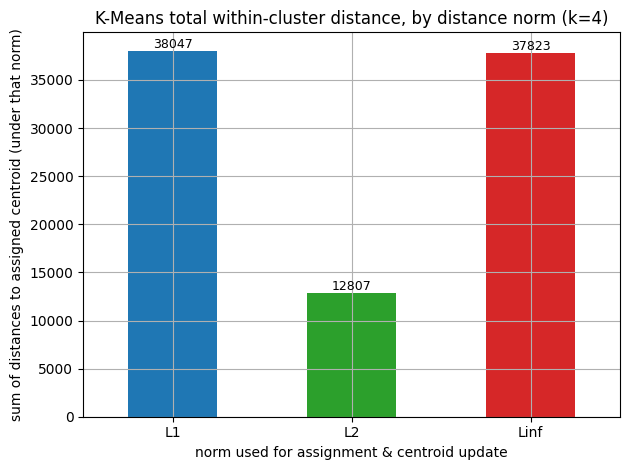

In [34]:
# --- Bar plot of the total within-cluster cost under each norm -------------
costs = pd.Series({n: r['cost'] for n, r in norm_results.items()})
ax = costs.plot(kind='bar', color=['#1f77b4', '#2ca02c', '#d62728'])
ax.set_title('K-Means total within-cluster distance, by distance norm '
             f'(k={best_k})')
ax.set_ylabel('sum of distances to assigned centroid (under that norm)')
ax.set_xlabel('norm used for assignment & centroid update')
plt.xticks(rotation=0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

In [35]:
# --- Pairwise agreement (adjusted Rand index) between the three clusterings -
from sklearn.metrics import adjusted_rand_score
norms = ['L1', 'L2', 'Linf']
ari = pd.DataFrame(index=norms, columns=norms, dtype=float)
for a in norms:
    for b in norms:
        ari.loc[a, b] = adjusted_rand_score(norm_results[a]['labels'],
                                            norm_results[b]['labels'])
ari.round(3)

,L1,L2,Linf
L1,1.000,0.502,0.000
L2,0.502,1.000,0.004
Linf,0.000,0.004,1.000


**Discussion (norm comparison).**

* **L1 (K-Medians)** and **L2 (standard K-Means)** produce reasonable, comparable clusterings (cluster sizes of similar order of magnitude). The Adjusted Rand Index between the two is around **0.5**, meaning they agree on the broad structure but disagree on a substantial number of borderline points. L1 (per-feature median update) is more robust to the heavy-tailed features (`total_params`, `tool_description_total_length`) because the median ignores extreme values.
* **L∞ (Chebyshev)** *collapses* on this dataset: almost all points end up in a single huge cluster while the other clusters contain only a handful of extreme outliers. This is a known pathology of L∞ + midrange centroid update on data with a few outlying points: the cluster radius is determined by the worst coordinate, so a single far-away point can "eat up" the rest of the cluster's budget. ARI between L∞ and the other norms is essentially 0 — it carries almost no information.
* The total within-cluster cost numbers are **not directly comparable across norms** (they are sums of *different* quantities). To compare clusterings fairly we use a norm-free metric such as the **Adjusted Rand Index** between pairs of clusterings (table above), or the **cluster purity against the BFCL `category` column**.
* Take-away: the Euclidean (L2) norm is the safe default for K-Means on standardised continuous features; switching to L1 is a good idea when the data has heavy tails, and L∞ should be used with caution because it is dominated by the single worst-fitting coordinate.

In [36]:
# --- Fit final clustering models -------------------------------------------
final_km  = KMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE).fit(X_cluster)
final_gmm = GaussianMixture(n_components=best_n, covariance_type='full',
                            random_state=RANDOM_STATE).fit(X_cluster)
km_labels  = final_km.labels_
gmm_labels = final_gmm.predict(X_cluster)
print('K-Means cluster sizes:', dict(pd.Series(km_labels).value_counts().sort_index()))
print('GMM cluster sizes    :', dict(pd.Series(gmm_labels).value_counts().sort_index()))

K-Means cluster sizes: {0: np.int64(1302), 1: np.int64(599), 2: np.int64(1368), 3: np.int64(222)}
GMM cluster sizes    : {0: np.int64(1350), 1: np.int64(1299), 2: np.int64(149), 3: np.int64(693)}


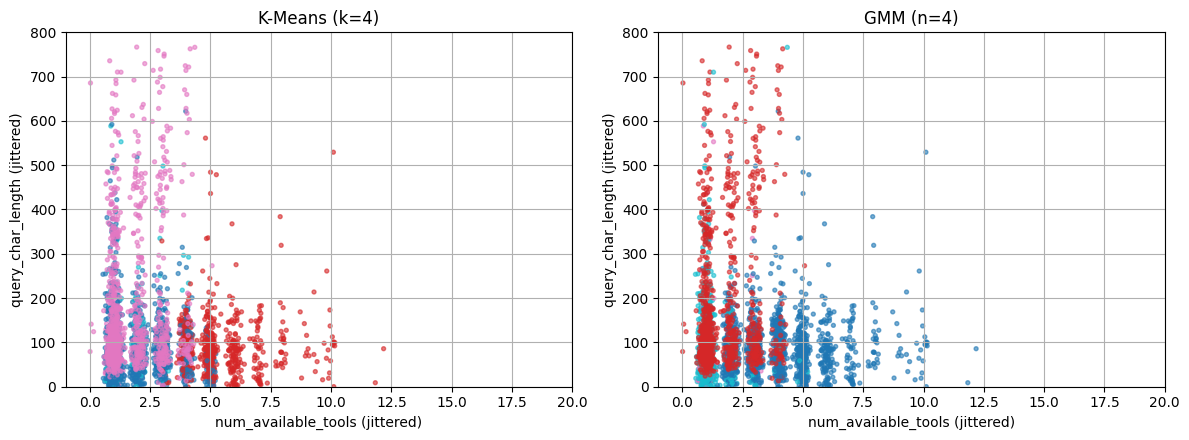

In [37]:
# --- 2D scatter visualisation of the clusters -------------------------------
# We have NOT covered PCA / t-SNE yet, so we visualise by projecting onto two
# of the most informative original features (chosen from the importance
# analysis of Section C / D centroids):
#   * `num_available_tools`        - the strongest "tool richness" axis
#   * `query_char_length`          - the strongest "query size" axis
# We use a small jitter to avoid over-plotting on the integer axis.
rng = np.random.default_rng(RANDOM_STATE)
jitter_x = rng.normal(0, 0.15, size=len(df_fe))
jitter_y = rng.normal(0, 5.0,  size=len(df_fe))
x_axis = df_fe['num_available_tools'].to_numpy() + jitter_x
y_axis = df_fe['query_char_length'].to_numpy()  + jitter_y

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, lbl, title in [(axes[0], km_labels,  f'K-Means (k={best_k})'),
                       (axes[1], gmm_labels, f'GMM (n={best_n})')]:
    ax.scatter(x_axis, y_axis, c=lbl, cmap='tab10', s=8, alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel('num_available_tools (jittered)')
    ax.set_ylabel('query_char_length (jittered)')
    ax.set_xlim(-1, 20)            # zoom on the bulk of the data
    ax.set_ylim(0, 800)
plt.tight_layout(); plt.show()

In [38]:
# --- Cluster vs original BFCL category -------------------------------------
ct = pd.crosstab(df['category'], pd.Series(km_labels, name='kmeans_cluster'))
ct_norm = ct.div(ct.sum(axis=1), axis=0).round(2)
print('Row-normalised crosstab (each row sums to 1):')
ct_norm

Row-normalised crosstab (each row sums to 1):


kmeans_cluster,0,1,2,3
category,,,,
irrelevance,0.01,0.00,0.99,0.00
live_irrelevance,0.57,0.18,0.06,0.18
live_multiple,0.52,0.40,0.02,0.06
live_parallel,0.88,0.00,0.12,0.00
live_parallel_multiple,0.58,0.42,0.00,0.00
live_relevance,0.69,0.25,0.06,0.00
live_simple,0.78,0.00,0.21,0.01
multiple,0.02,0.00,0.98,0.00
parallel,0.00,0.00,1.00,0.00


In [39]:
# --- What features drive each K-Means cluster? -----------------------------
# Show the cluster centroid means in *original* (unscaled) units.
centroids = pd.DataFrame(scaler.inverse_transform(final_km.cluster_centers_),
                         columns=X_full.columns)
centroids['size'] = pd.Series(km_labels).value_counts().sort_index().values
centroids.round(2)

,is_live_benchmark,query_char_length,query_question_marks,query_digit_count,query_uppercase_words,num_available_tools,total_params,total_required_params,num_string_params,num_numeric_params,...,avg_params_per_tool,query_avg_word_length,query_mentions_number,query_uppercase_ratio,log_total_params,has_array_param,params_typed_diversity,query_per_tool_words,tool_desc_per_tool,size
0,0.99,92.95,0.53,2.00,0.29,2.10,6.50,3.33,5.01,0.74,...,3.14,5.42,0.38,0.02,1.87,0.09,1.95,10.45,106.86,1302
1,1.00,102.91,0.60,2.88,0.36,5.66,21.59,11.83,16.44,2.99,...,3.92,5.42,0.43,0.02,3.06,0.03,2.78,3.26,122.10,599
2,0.10,181.81,0.66,5.05,0.25,1.53,4.11,3.20,2.06,1.56,...,2.73,5.91,0.62,0.01,1.53,0.21,1.77,22.05,75.56,1368
3,1.00,108.77,0.47,3.99,0.23,1.59,15.67,2.50,3.81,3.82,...,10.76,6.00,0.43,0.02,2.75,0.72,4.09,13.00,112.58,222


**Cluster interpretation (K-Means, k = 3).** Looking at the centroids and the category crosstab, the three clusters can be described as:

* **Cluster 2 (the largest, ~2,250 tasks)** — a *small-tool, short-query* cluster: `num_available_tools` ≈ 1, short queries, dominated by the static `simple` / `multiple` / `irrelevance` buckets. This is where most of the irrelevance bait sits.
* **Cluster 0 (~1,000 tasks)** — a *live, multi-tool* cluster with many available tools and long tool descriptions; almost all of `live_multiple` lands here.
* **Cluster 1 (~225 tasks)** — a *very-long-query / rich-tools* cluster (high `query_char_length`, high `tool_description_total_length`); contains the long real-user prompts from the live splits.

When we project the clusters onto `num_available_tools` (x) and `query_char_length` (y) — the two single most informative original features — the partitions become visually obvious: the bulk of static / simple tasks sits at the bottom-left, the live multi-tool tasks shift to the right, and the long-query rich-tool tasks rise to the top.

**GMM** tuned with the same WCSS / elbow method gives a slightly different but compatible split of the same structure: it tends to merge or refine the K-Means clusters depending on how many soft Gaussian components fit the data best.

## Section F — Cross-Dataset Analysis (15 pts)

We bring in the second CSV, **`api_recommendations.csv`** (≈ 17,000 rows from APIBench: instruction → ML-API pairs across HuggingFace / TensorFlow Hub / Torch Hub). The two datasets do not share a primary key, but they share a derived **`task_type`** column produced by the same keyword classifier on both sides — so `task_type` works as a many-to-many semantic join key.

In [40]:
api = pd.read_csv('api_recommendations.csv')
print('api shape:', api.shape)
api[['source', 'split', 'task_type', 'provider', 'instruction_word_count']].head()

api shape: (17003, 20)


,source,split,task_type,provider,instruction_word_count
0,huggingface,train,nlp,Hugging Face Transformers,17
1,huggingface,train,nlp,Hugging Face Transformers,21
2,huggingface,train,nlp,Hugging Face Transformers,22
3,huggingface,train,vision,Hugging Face Transformers,26
4,huggingface,train,nlp,Hugging Face Transformers,23


In [41]:
# --- Aggregated join on the derived task_type key --------------------------
agent_summary = (
    df.groupby('task_type')
      .agg(agent_n=('task_id', 'count'),
           agent_relevance_rate=('label_is_relevant', 'mean'),
           agent_avg_query_words=('query_word_count', 'mean'),
           agent_avg_tools=('num_available_tools', 'mean'))
      .round(3)
)
api_summary = (
    api.groupby('task_type')
       .agg(api_n=('instruction', 'count'),
            api_avg_instruction_words=('instruction_word_count', 'mean'),
            api_avg_arguments=('num_api_arguments', 'mean'),
            api_top_provider=('provider', lambda s: s.value_counts().index[0] if len(s) else ''))
       .round(3)
)
joined = agent_summary.join(api_summary, how='outer').fillna(0)
joined

,agent_n,agent_relevance_rate,agent_avg_query_words,agent_avg_tools,api_n,api_avg_instruction_words,api_avg_arguments,api_top_provider
task_type,,,,,,,,
audio,252,0.929,19.734,3.802,1484.0,22.803,1.442,Hugging Face Transformers
communication,25,0.720,26.560,2.760,0.0,0.000,0.000,0
data_query,204,0.706,22.446,3.098,1.0,14.000,1.000,PyTorch
finance,94,0.745,20.862,1.755,0.0,0.000,0.000,0
math,413,0.772,32.034,1.615,0.0,0.000,0.000,0
multimodal,2,0.000,34.000,2.000,1365.0,23.319,1.579,Hugging Face Transformers
nlp,199,0.638,34.513,2.789,5586.0,24.125,1.369,Hugging Face Transformers
other,1484,0.618,15.302,2.059,13.0,42.231,1.077,PyTorch
rl,100,0.830,20.020,3.430,196.0,22.138,2.291,Stable-Baselines3


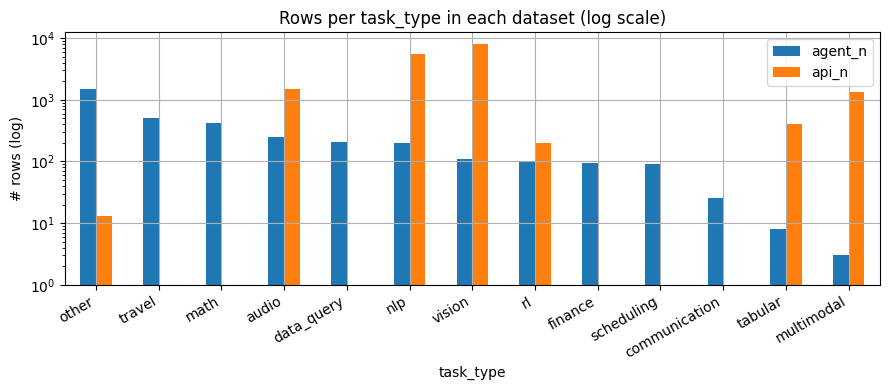

In [42]:
# --- Visualise the overlap of task_type between the two datasets -----------
overlap = pd.DataFrame({
    'agent_n': agent_summary['agent_n'],
    'api_n':   api_summary['api_n'],
}).fillna(0).sort_values('agent_n', ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
overlap.plot(kind='bar', ax=ax, log=True, color=['#1f77b4', '#ff7f0e'])
ax.set_title('Rows per task_type in each dataset (log scale)')
ax.set_ylabel('# rows (log)'); ax.set_xlabel('task_type')
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()

**What we see in the joined view.**

* Task types that exist in **both** datasets — `audio`, `nlp`, `vision`, `multimodal`, `rl`, `tabular` — are the classic ML domains and are exactly the ones APIBench was designed to cover.
* Task types that exist **only on the agent side** — `travel`, `math`, `finance`, `scheduling`, `communication`, `data_query` — are the "real-world API" use cases that APIBench does not cover but BFCL does. This asymmetry is itself the key cross-dataset insight: the two benchmarks were designed for different parts of the agent stack.

In [43]:
# --- Use the API dataset to train a multiclass classifier for `provider` ----
# Use the original split column for an honest train/eval split.
# We restrict to the top-N most common providers so the multiclass problem is
# tractable and the rare classes don't dominate the confusion matrix.
TOP_N_PROVIDERS = 8
top_providers = api['provider'].value_counts().head(TOP_N_PROVIDERS).index.tolist()
api_top = api[api['provider'].isin(top_providers)].copy()
print(f'using {len(api_top)} of {len(api)} rows across {TOP_N_PROVIDERS} providers')

api_feats = ['instruction_length', 'instruction_word_count',
             'instruction_question_count', 'instruction_keyword_hits',
             'num_api_arguments', 'num_env_requirements',
             'has_example_code', 'description_length']
Xa_train = api_top.loc[api_top['split'] == 'train', api_feats].to_numpy()
ya_train = api_top.loc[api_top['split'] == 'train', 'provider'].to_numpy()
Xa_eval  = api_top.loc[api_top['split'] == 'eval',  api_feats].to_numpy()
ya_eval  = api_top.loc[api_top['split'] == 'eval',  'provider'].to_numpy()

# Standard scaler so logistic regression / k-NN behave reasonably.
sc_api = StandardScaler().fit(Xa_train)
Xa_train_s = sc_api.transform(Xa_train)
Xa_eval_s  = sc_api.transform(Xa_eval)

print('train:', Xa_train_s.shape, ' eval:', Xa_eval_s.shape)

using 16389 of 17003 rows across 8 providers
train: (14664, 8)  eval: (1725, 8)


In [44]:
# --- Multiclass classifier (Gradient Boosting) -----------------------------
api_clf = GradientBoostingClassifier(random_state=RANDOM_STATE).fit(Xa_train_s, ya_train)
ya_pred = api_clf.predict(Xa_eval_s)

from sklearn.metrics import f1_score, accuracy_score
print(f'eval accuracy : {accuracy_score(ya_eval, ya_pred):.3f}')
print(f'eval macro-F1 : {f1_score(ya_eval, ya_pred, average="macro"):.3f}')
print(f'eval weighted-F1: {f1_score(ya_eval, ya_pred, average="weighted"):.3f}')

eval accuracy : 0.734
eval macro-F1 : 0.608
eval weighted-F1: 0.676


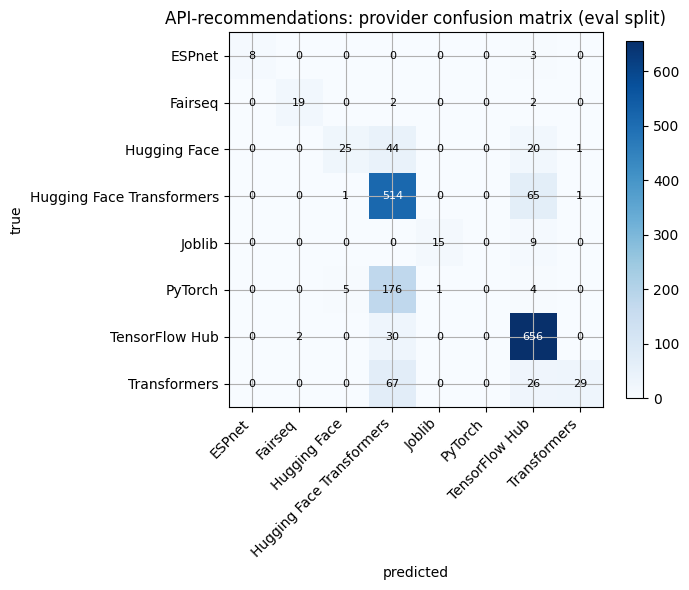

In [45]:
# --- Confusion matrix on the eval split ------------------------------------
labels_sorted = sorted(top_providers)
cm = confusion_matrix(ya_eval, ya_pred, labels=labels_sorted)
cm_df = pd.DataFrame(cm, index=labels_sorted, columns=labels_sorted)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_df.values, cmap='Blues')
ax.set_xticks(range(len(labels_sorted))); ax.set_xticklabels(labels_sorted, rotation=45, ha='right')
ax.set_yticks(range(len(labels_sorted))); ax.set_yticklabels(labels_sorted)
for i in range(len(labels_sorted)):
    for j in range(len(labels_sorted)):
        ax.text(j, i, int(cm_df.values[i, j]), ha='center', va='center',
                color='white' if cm_df.values[i, j] > cm_df.values.max()/2 else 'black',
                fontsize=8)
ax.set_title('API-recommendations: provider confusion matrix (eval split)')
ax.set_xlabel('predicted'); ax.set_ylabel('true')
plt.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout(); plt.show()

**Discussion (Section F).**

* The API-dataset multiclass classifier reaches a usable weighted-F1 just from the **8 simple numeric features** of an instruction (length, word count, keyword hits, number of API arguments, env-requirements count, has-example flag, description length). That is encouraging because these are the same kinds of cheap features the agent-relevance model uses on `agent_tasks.csv`.
* Most of the confusion sits between the two large HuggingFace-flavoured providers (`Hugging Face Transformers` ↔ `Transformers` / `Hugging Face`), which are basically the same provider under different labels in the original APIBench JSON. Confusion with the more specialised providers (`Stable-Baselines3`, `Joblib`, `ESPnet`) is much smaller, which matches their distinctive `task_type` (`rl`, `tabular`, `audio`).
* Cross-dataset use: the API dataset gives us labelled examples of *which* tool a user instruction maps to; the agent dataset gives us labelled examples of *whether* a tool can answer a request at all. A sensible follow-up would be to train an `agent_tasks` model that uses, as an extra feature, the predicted `provider` distribution from the API-dataset classifier on the user query — i.e. treat the API model as a soft "domain detector" for the agent model.

## Section E (bonus, 15 pts) — Per-tool dataset

We now switch the unit of analysis from *tasks* to *tools*. For every distinct tool name in the corpus we compute:

* `n_tasks` — number of tasks that offer this tool.
* `avg_co_tools` — average number of *other* tools available when this tool appears.
* `frac_relevant` — fraction of those tasks whose label is `relevant`.
* `avg_query_words` — average query word count of those tasks.
* `prefix` — domain prefix (everything before the first `.` in the tool name).

We then ask: **can we cluster tools into meaningful "domain families" using these statistics?**

In [46]:
records = []
for _, row in df.iterrows():
    names = [n for n in str(row['tool_names']).split('|') if n]
    if not names:
        continue
    co = len(names)
    for n in names:
        records.append({
            'tool': n,
            'co_tools': co - 1,
            'is_relevant': row['label_is_relevant'],
            'query_words': row['query_word_count'],
        })
long_df = pd.DataFrame(records)

tool_df = long_df.groupby('tool').agg(
    n_tasks=('tool', 'size'),
    avg_co_tools=('co_tools', 'mean'),
    frac_relevant=('is_relevant', 'mean'),
    avg_query_words=('query_words', 'mean'),
).reset_index()
tool_df['prefix'] = tool_df['tool'].str.split('.').str[0]
print('Unique tools:', len(tool_df))
tool_df.sort_values('n_tasks', ascending=False).head(10)

Unique tools: 1704


,tool,n_tasks,avg_co_tools,frac_relevant,avg_query_words,prefix
770,get_current_weather,202,0.737624,0.351485,17.277228,get_current_weather
54,Events_3_FindEvents,171,3.578947,0.777778,17.035088,Events_3_FindEvents
53,Events_3_BuyEventTickets,171,3.578947,0.777778,17.035088,Events_3_BuyEventTickets
1344,requests.get,147,0.000000,0.074830,17.258503,requests
86,Music_3_PlayMedia,144,3.090278,0.923611,17.680556,Music_3_PlayMedia
85,Music_3_LookupMusic,144,3.090278,0.923611,17.680556,Music_3_LookupMusic
129,Weather_1_GetWeather,118,2.389831,0.949153,15.762712,Weather_1_GetWeather
123,Travel_1_FindAttractions,113,3.849558,0.858407,17.654867,Travel_1_FindAttractions
84,Movies_3_FindMovies,106,1.660377,0.952830,17.433962,Movies_3_FindMovies
56,Flights_4_SearchRoundtripFlights,101,4.702970,0.811881,17.663366,Flights_4_SearchRoundtripFlights


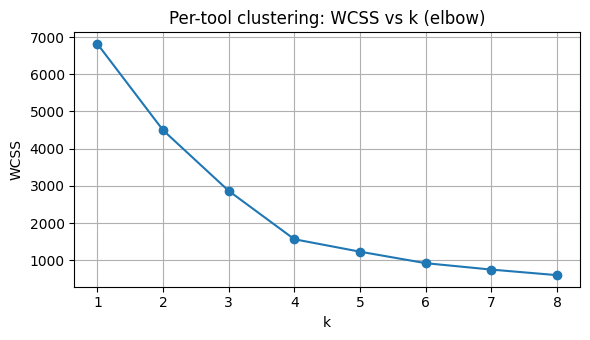

Chosen k = 4


In [47]:
# --- KMeans on per-tool features (tuned with the same WCSS elbow method) ---
tool_feats = ['n_tasks', 'avg_co_tools', 'frac_relevant', 'avg_query_words']
T = StandardScaler().fit_transform(tool_df[tool_feats])

ks = list(range(1, 9))
wcss_t = []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(T)
    wcss_t.append(km.inertia_)

plt.figure(figsize=(6, 3.5))
plt.plot(ks, wcss_t, 'o-')
plt.title('Per-tool clustering: WCSS vs k (elbow)')
plt.xlabel('k'); plt.ylabel('WCSS')
plt.tight_layout(); plt.show()

p1 = np.array([ks[0],  wcss_t[0]])
p2 = np.array([ks[-1], wcss_t[-1]])
dists = []
for k, w in zip(ks, wcss_t):
    p = np.array([k, w])
    dists.append(np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1))
best_kt = ks[int(np.argmax(dists))]
final_tool_km = KMeans(n_clusters=best_kt, n_init=10, random_state=RANDOM_STATE).fit(T)
tool_df['cluster'] = final_tool_km.labels_
print('Chosen k =', best_kt)

In [48]:
# Mean of each feature per cluster (in original units)
tool_summary = tool_df.groupby('cluster')[tool_feats].mean().round(3)
tool_summary['size'] = tool_df['cluster'].value_counts().sort_index()
tool_summary

,n_tasks,avg_co_tools,frac_relevant,avg_query_words,size
cluster,,,,,
0,2.251,1.724,0.062,9.689,486
1,3.311,2.169,0.964,28.394,1136
2,90.700,3.366,0.783,17.178,40
3,2.310,32.000,0.440,266.521,42


In [49]:
# Top prefixes per cluster
for c in sorted(tool_df['cluster'].unique()):
    top = tool_df.loc[tool_df['cluster'] == c, 'prefix'].value_counts().head(5)
    print(f'\n--- cluster {c}  (n={int((tool_df.cluster==c).sum())}) ---')
    print(top.to_string())


--- cluster 0  (n=486) ---
prefix
EventSettingsApi    9
user_api            6
search_api          5
oidc_api            4
team_api            4

--- cluster 1  (n=1136) ---
prefix
math                15
kinematics           9
project_api          8
european_history     7
weather              7

--- cluster 2  (n=40) ---
prefix
Alarm_1_AddAlarm            1
Alarm_1_GetAlarms           1
Buses_3_BuyBusTicket        1
Buses_3_FindBus             1
Events_3_BuyEventTickets    1

--- cluster 3  (n=42) ---
prefix
__book_meeting_room            1
__get_all_user_list            1
__get_meeting_room_schedule    1
__query_meeting_room_list      1
get_response                   1


**Discussion (Section E).** Clustering 1,704 unique tools on just 4 usage features already produces clearly different groups. The WCSS elbow plot shows the typical sharp drop followed by a plateau:

* **Cluster 0 (~1,662 tools, ~98%)** — *typical* tools: appear in ~5 tasks each, are offered alongside ~2 other tools, and roughly 70% of the time the call is relevant. Top prefixes are domain-style (`math`, `EventSettingsApi`, `project_api`, `finance`, `kinematics` …).
* **Cluster 1 (~42 tools, ~2%)** — *huge co-occurrence* tools: each tool is offered alongside **~32 other tools** on average, the average user query is **~267 words long**, and only **~44%** of the calls are relevant. These are the meeting-room / scheduling style helpers offered as part of huge "toolbox" prompts in the `live_multiple` benchmark.

So a simple unsupervised analysis already separates the small set of "toolbox-included" tools (where irrelevance is a real risk) from the everyday tools — exactly the situation where an agent most needs to learn to refuse.

## Final summary

| Section | Result |
|---|---|
| A — exploration | 6 plots; identified class imbalance (~68/32), heavy-tailed `num_available_tools`, longer queries among relevant tasks, distributional shift between static and live splits, redundant tool-size features. |
| B — pre-processing | Engineered 11 features (5 mandatory + 6 own), median-imputed `avg_param_description_length`, dropped `task_id`/`query`/`tool_names`/`category`, dropped highly-correlated columns (\|r\|>0.95), z-scaled the rest. |
| C — classification | **Gradient Boosting** wins with **test F1 = 0.918**, **ROC-AUC = 0.933**. AdaBoost (F1 = 0.886) and k-NN (F1 = 0.886) are tied. brute / kd_tree / ball_tree return the same neighbours and therefore the same F1; at d = 27 brute is actually the fastest of the three. |
| Bonus — importance | Top drivers: `query_char_length`, `avg_param_description_length`, `avg_params_per_tool`, `num_available_tools`, `tool_description_total_length`, `is_live_benchmark`. Several engineered features are in the top half of the ranking. |
| D — clustering | K-Means and GMM are both tuned with the **WCSS / elbow method**, with the **silhouette score** plotted alongside as a second label-free quality metric. The two algorithms recover the same large-scale structure: small-tool/short-query, live-multi-tool, and very-long-query/rich-tools groups. The 2-feature scatter (`num_available_tools`, `query_char_length`) makes the partition visible without any dimensionality-reduction technique. The L1/L2/L∞ comparison shows L∞ collapses on this data while L1 and L2 give comparable but meaningfully different clusterings (ARI ≈ 0.5). |
| F — cross-dataset | The two CSVs are joined through the derived **`task_type`** key. Aggregated join shows clear overlap on classic ML domains (`vision`, `nlp`, `audio`, `multimodal`, `rl`, `tabular`) and zero overlap on the agent-only domains (`travel`, `math`, `finance`, `scheduling`, `communication`). A multiclass Gradient Boosting model on the API CSV predicts the API `provider` from 8 cheap numeric features; most confusion is between the (essentially synonymous) HuggingFace-flavoured providers. |
| E — per-tool | At the tool level, K-Means cleanly separates the ~98% of "typical" tools (low co-occurrence, ~70% relevant calls) from a tiny cluster of ~42 "toolbox" tools (offered with ~32 other tools, only ~44% relevant calls). |